In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import ImageDataset,model_create,evaluate_model,trainer,model_train,plot_confusion_matrix

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/cell/dataset'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((299,299)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.8913964755535125,train_accu=0.6469166666666667
Epoch=0,valid_loss=0.9238129741112519,valid_accu=0.6322006708473094
0
Epoch=1,train_loss=0.700313737710317,train_accu=0.72925
Epoch=1,valid_loss=0.781191502013637,valid_accu=0.6933061105439696
0
Epoch=2,train_loss=0.552729777554671,train_accu=0.7839583333333333
Epoch=2,valid_loss=0.6850820952086263,valid_accu=0.732827767245151
0
Epoch=3,train_loss=0.4865132210055987,train_accu=0.8061666666666667
Epoch=3,valid_loss=0.663361572777719,valid_accu=0.7434738223712994
0
Epoch=4,train_loss=0.37589831853906314,train_accu=0.8535416666666666
Epoch=4,valid_loss=0.6143750814440926,valid_accu=0.768120169170191
0
Epoch=5,train_loss=0.34266927040616674,train_accu=0.870125
Epoch=5,valid_loss=0.6332093675264868,valid_accu=0.7697243692576928
0
Epoch=6,train_loss=0.28387520610292755,train_accu=0.8965416666666667
Epoch=6,valid_loss=0.6079514165200696,valid_accu=0.7800787516406592
0
Epoch=7,train_loss=0.23328539618849756,train_accu=0.915958

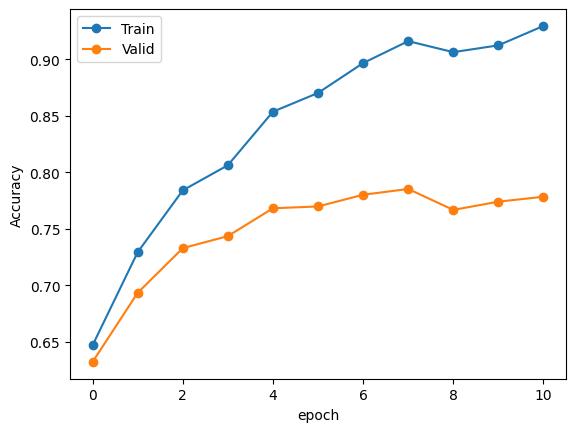

In [7]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_38.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0')
train_loss,train_accu

(0.23328539676467577, 0.9159583333333333)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0')
valid_loss,valid_accu

(0.5877967236213961, 0.7851830246463468)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

CC      0.882353
EC      0.909550
HGSC    0.956654
LGSC    0.840162
MC      0.905496
dtype: float64

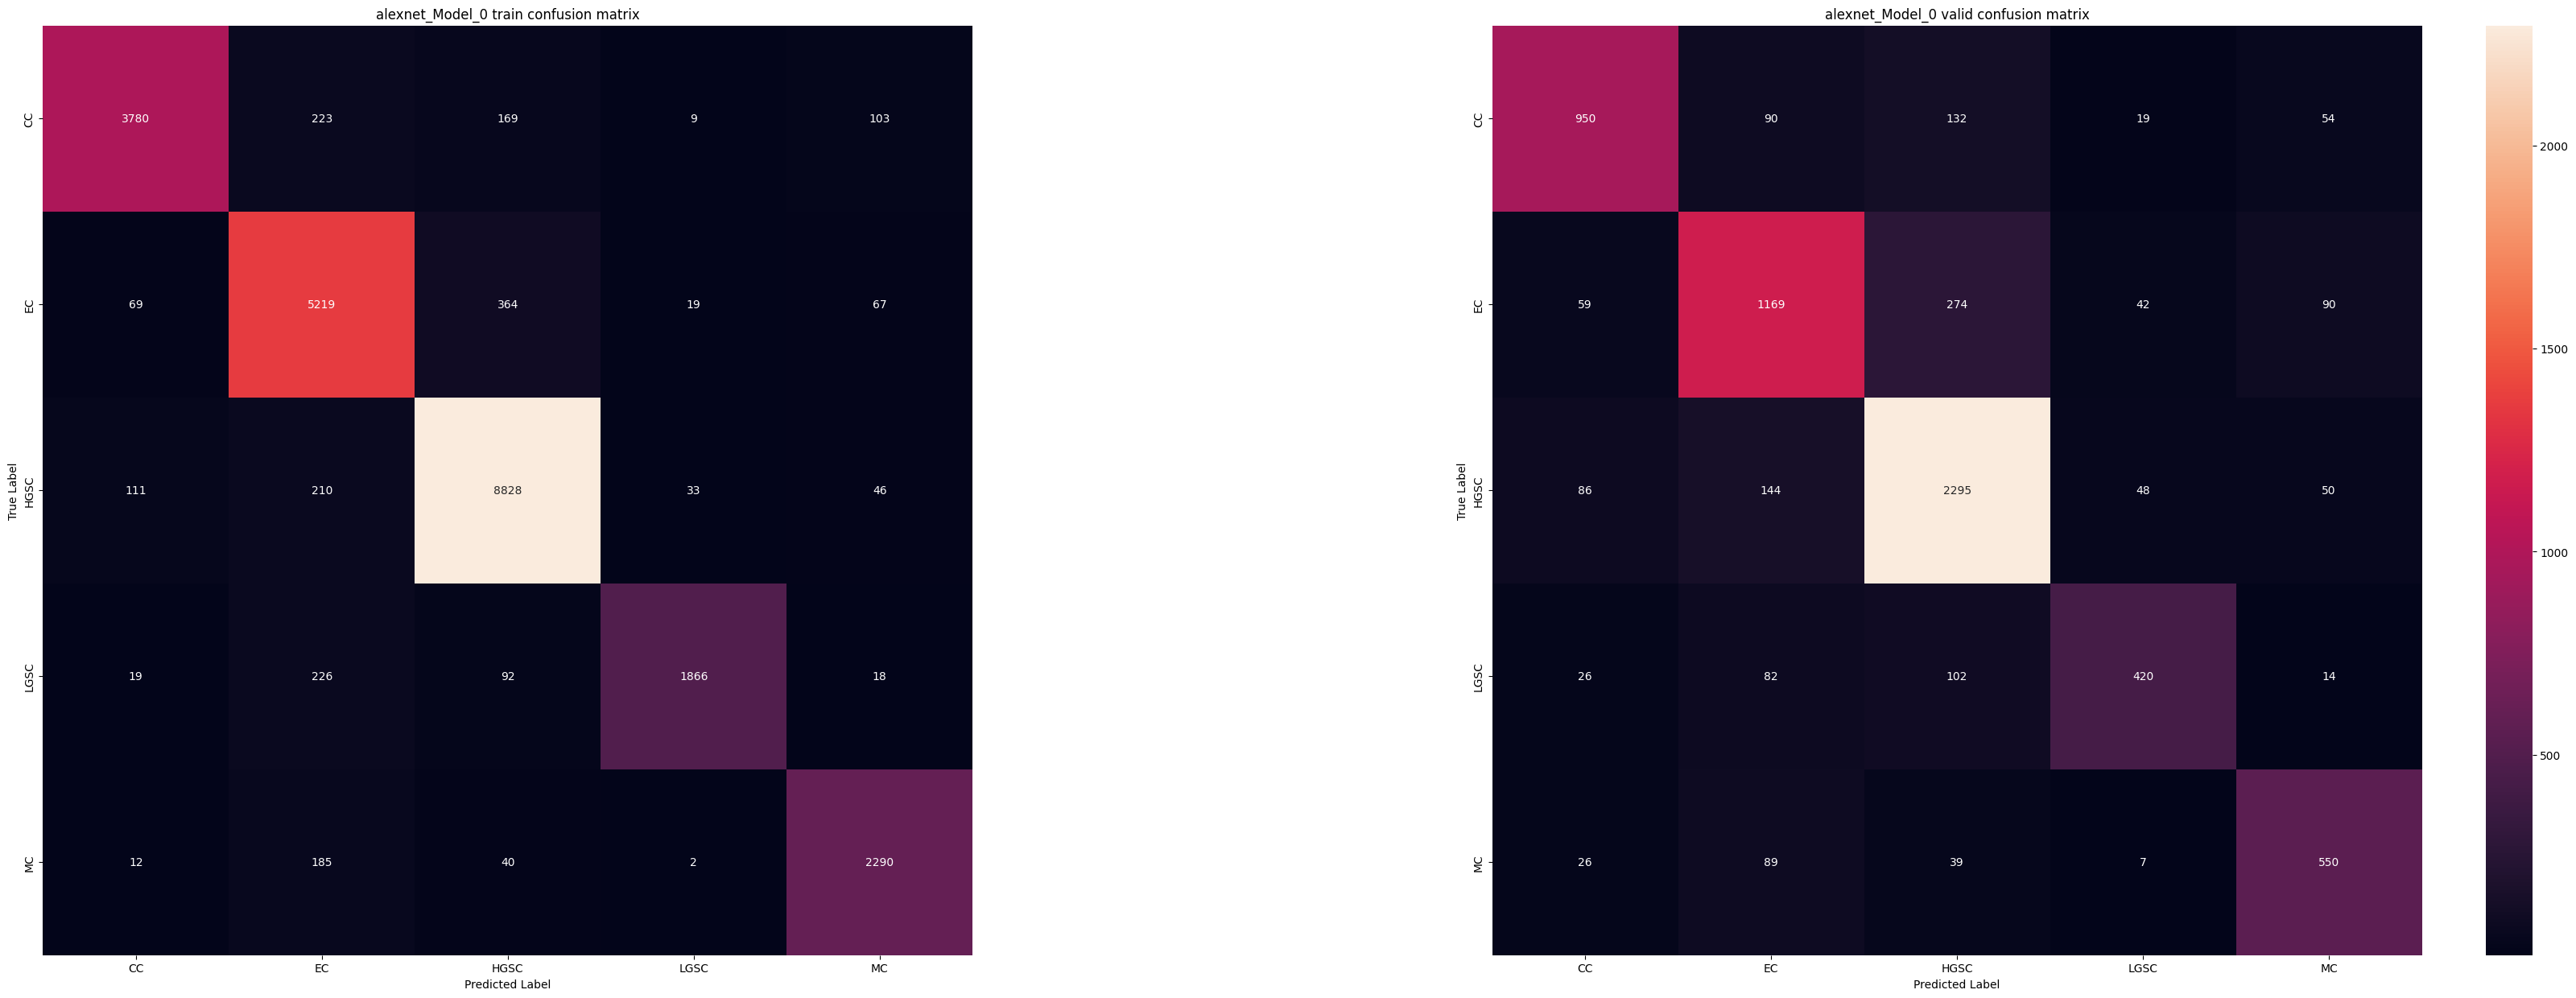

In [11]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)